# P.Raghu 25MML0029  (Number Plate Detection)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [6]:
BASE_PATH = "/content/drive/MyDrive/Number plate detection/archive"

IMAGE_PATH = BASE_PATH + "/images"
ANNOT_PATH = BASE_PATH + "/annotations"


In [7]:
import os

print("Total Images:", len(os.listdir(IMAGE_PATH)))
print("Total Annotations:", len(os.listdir(ANNOT_PATH)))


Total Images: 433
Total Annotations: 433


In [8]:
import cv2
import numpy as np

images = []
labels = []

for img_file in os.listdir(IMAGE_PATH):

    img_path = os.path.join(IMAGE_PATH, img_file)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # Feature engineering
    img = cv2.resize(img,(128,128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)

    images.append(blur)
    labels.append(1)   # plate present

images = np.array(images)/255.0
images = images.reshape(-1,128,128,1)

print(images.shape)


(433, 128, 128, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(
    images,
    np.array(labels),
    epochs=10,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.9187 - loss: 0.1211 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 8.3545e-42 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 7.0065e-44 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 7.5670e-44 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 6.4374e-40 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 4.7765e-40 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accur

In [12]:
!apt-get install tesseract-ocr -y
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [18]:
import cv2
import matplotlib.pyplot as plt

def detect_and_show_plate(image_path):

    img = cv2.imread(image_path)
    img_copy = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.bilateralFilter(gray,11,17,17)
    edges = cv2.Canny(blur,30,200)

    contours,_ = cv2.findContours(
        edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    plate = None

    for c in contours:
        peri = cv2.arcLength(c,True)
        approx = cv2.approxPolyDP(c,0.02*peri,True)

        if len(approx) == 4:
            x,y,w,h = cv2.boundingRect(c)
            plate = img[y:y+h, x:x+w]

            # Draw bounding box
            cv2.rectangle(img_copy,(x,y),(x+w,y+h),(0,255,0),3)
            break

    # Show original image with detection
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.title("Detected Number Plate")
    plt.axis("off")

    # Show cropped plate
    if plate is not None:
        plt.subplot(1,2,2)
        plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Plate")
        plt.axis("off")

    plt.show()

    return plate


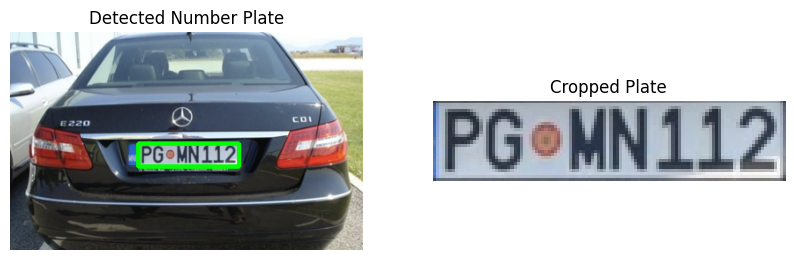

array([[[ 91,  59,  42],
        [ 99,  82,  70],
        [ 97,  93,  85],
        ...,
        [158, 149, 138],
        [127, 116, 106],
        [ 83,  70,  63]],

       [[138,  86,  62],
        [172, 140, 123],
        [183, 170, 158],
        ...,
        [193, 185, 174],
        [167, 158, 148],
        [100,  89,  81]],

       [[161,  93,  62],
        [192, 149, 126],
        [202, 180, 164],
        ...,
        [196, 186, 175],
        [178, 167, 158],
        [109,  98,  90]],

       ...,

       [[200, 120,  88],
        [234, 182, 158],
        [227, 199, 182],
        ...,
        [244, 244, 244],
        [198, 196, 195],
        [133, 130, 124]],

       [[177, 111,  82],
        [221, 177, 157],
        [216, 195, 180],
        ...,
        [231, 230, 230],
        [177, 175, 173],
        [101,  98,  92]],

       [[118,  75,  52],
        [136, 108,  91],
        [126, 112,  99],
        ...,
        [131, 129, 128],
        [110, 106, 104],
        [ 75,  69,  65]]], dtype=uint8)

In [19]:
detect_and_show_plate(IMAGE_PATH + "/Cars1.png")

In [13]:
import pytesseract

def extract_text(plate_img):
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    gray = cv2.threshold(gray,150,255,cv2.THRESH_BINARY)[1]

    text = pytesseract.image_to_string(gray, config='--psm 8')
    return text


In [17]:
test_img = IMAGE_PATH + "/Cars1.png"

plate = detect_plate(test_img)

if plate is not None:
    print("Plate detected")

    text = extract_text(plate)
    print("Number:", text)

else:
    print("Plate not detected")


Plate detected
Number: PGeMN112

